In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Using a sample for visualizations to ensure the notebook runs fast 
# since the dataset has 1 million rows.
# path = kagglehub.dataset_download("sharmajicoder/gen-z-social-media-usage-dataset")
df = pd.read_csv('genz_social_media_usage_1M.csv')
df_sample = df.sample(n=10000, random_state=42)
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


--- Central Tendency for Daily Usage Hours ---
Mean: 3.51
Median: 3.50
Mode (approx): 0.50


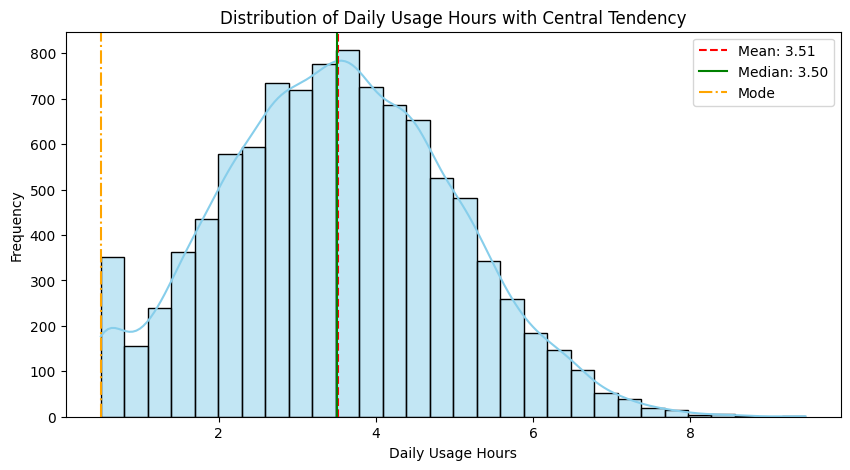

In [3]:
# 1. Central tendency of data (Visual; Numeric)
col = 'daily_usage_hours'

# Numeric
mean_val = df[col].mean()
median_val = df[col].median()
mode_val = df[col].mode()[0]

print("--- Central Tendency for Daily Usage Hours ---")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Mode (approx): {mode_val:.2f}")

# Visual
plt.figure(figsize=(10, 5))
sns.histplot(df_sample[col], bins=30, kde=True, color='skyblue')
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='-.', label=f'Mode')
plt.title('Distribution of Daily Usage Hours with Central Tendency')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Frequency')
plt.legend()
plt.show()

--- Outlier Identification ---
Lower Bound: -2.09, Upper Bound: 51.99
Number of outliers detected in originally sampled data: 47


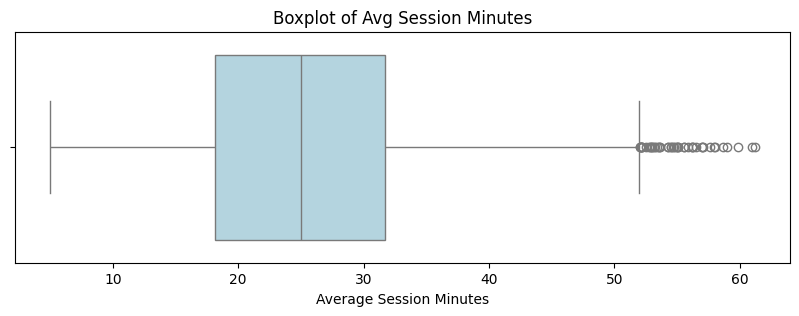

In [9]:
# 2. Outlier identification (Visual ; Numeric).
col_outlier = 'avg_session_minutes'

# Numeric approach: IQR Method
Q1 = df_sample[col_outlier].quantile(0.25)
Q3 = df_sample[col_outlier].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_detected = df_sample[(df_sample[col_outlier] < lower_bound) | (df_sample[col_outlier] > upper_bound)]

print("--- Outlier Identification ---")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Number of outliers detected in originally sampled data: {len(outliers_detected)}")

# Visual approach: Boxplot 
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_sample[col_outlier], color='lightblue', orient='h')
plt.title('Boxplot of Avg Session Minutes')
plt.xlabel('Average Session Minutes')
plt.show()

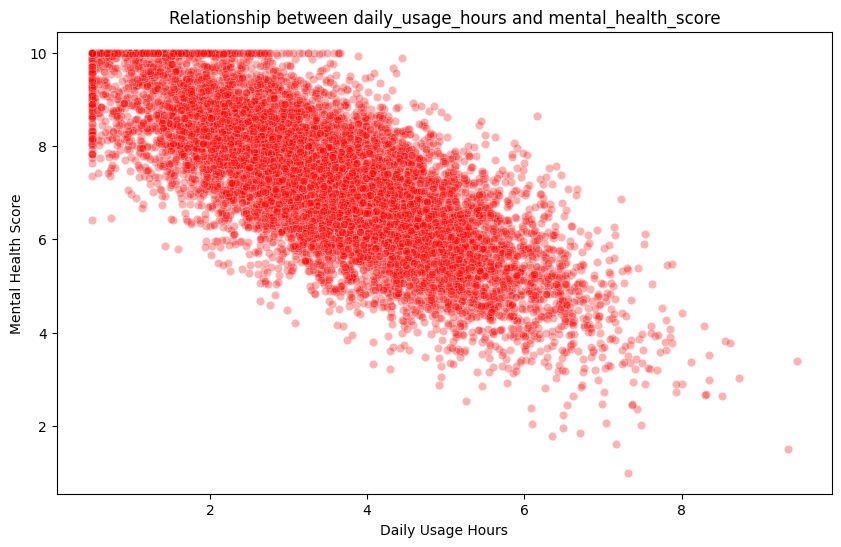

In [10]:
# 3. Visualizing relationship between 2 numeric variables
numeric_x = 'daily_usage_hours'
numeric_y = 'mental_health_score'

plt.figure(figsize=(10, 6))
# Using a scatter plot. We use alpha and a hexbin/kdeplot if points are too dense, 
# but scatter plot with alpha=0.3 is standard.
sns.scatterplot(x=numeric_x, y=numeric_y, data=df_sample, alpha=0.3, color='red')
plt.title(f'Relationship between {numeric_x} and {numeric_y}')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Mental Health Score')
plt.show()

/var/folders/yk/wn85kzvd4q5gmg0k8pnjvpw00000gn/T/ipykernel_30736/220234412.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=nominal_col, y=numeric_col, data=df_sample, palette='Set2')


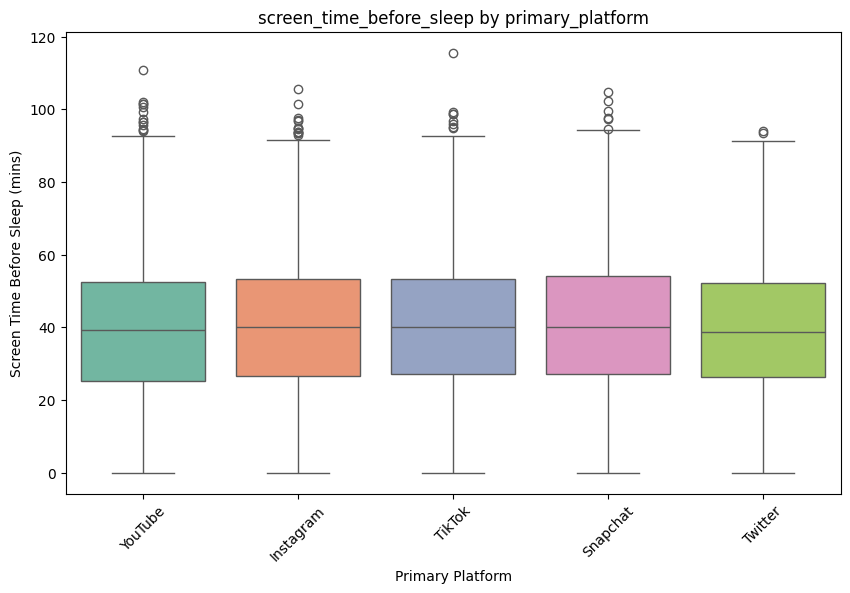

In [18]:
# 4. Visualizing relationship between numeric and nominal variable
nominal_col = 'primary_platform'
numeric_col = 'screen_time_before_sleep'

plt.figure(figsize=(10, 6))
sns.boxplot(x=nominal_col, y=numeric_col, data=df_sample, palette='Set2')
plt.title(f'{numeric_col} by {nominal_col}')
plt.xlabel('Primary Platform')
plt.ylabel('Screen Time Before Sleep (mins)')
plt.xticks(rotation=45)
plt.show()

--- Contingency Table ---


gender,Female,Male,Other
primary_platform,,,
Instagram,1477,1385,116
Snapchat,473,506,42
TikTok,1171,1223,97
Twitter,489,464,44
YouTube,1244,1179,90


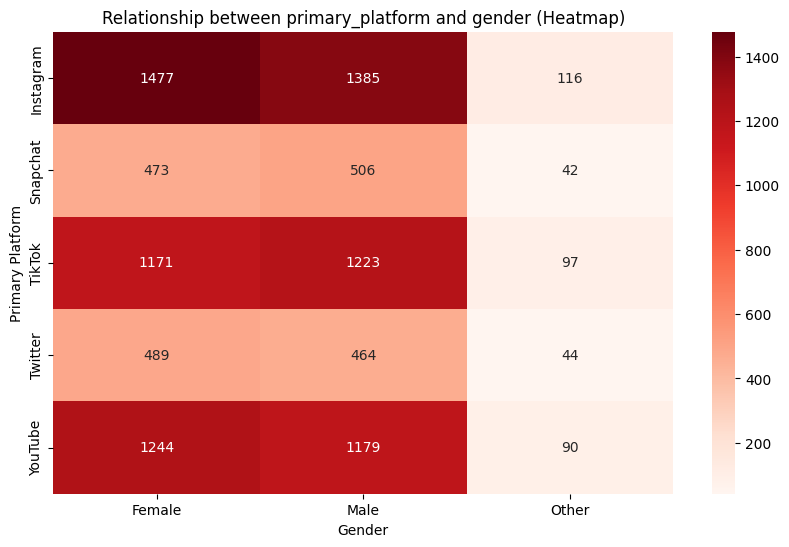

In [16]:
# 5. Visualizing relationship between two nominal variables
nominal_1 = 'primary_platform'
nominal_2 = 'gender'

# Create a contingency table
crosstab = pd.crosstab(df_sample[nominal_1], df_sample[nominal_2])

print("--- Contingency Table ---")
display(crosstab)

# Plotting a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Reds')
plt.title(f'Relationship between {nominal_1} and {nominal_2} (Heatmap)')
plt.xlabel('Gender')
plt.ylabel('Primary Platform')
plt.show()